# makemore, Part 2 — a Multi-Layer Perceptron Language Model, Explained in Runnable Code

> Andrej Karpathy. *makemore* — *“Building makemore Part 2: MLP.”*
> Implements **Bengio, Ducharme, Vincent & Jauvin (2003), *A Neural Probabilistic Language Model*** —
> [JMLR](https://www.jmlr.org/papers/v3/bengio03a.html).

Part 1's bigram model could only see **one** previous character. To do better we need **more context** —
but a plain count table over $k$ previous characters has $27^{k}$ rows and becomes hopeless almost
immediately (a trigram table is already 19,683 rows; most stay empty). Bengio's 2003 paper showed the way
out: instead of a giant sparse table, **learn a dense vector ("embedding") for each character** and feed a
window of them through a small **multi-layer perceptron (MLP)** that outputs the next-character
distribution. Characters that behave alike end up with nearby embeddings, so the model *generalizes*
across contexts it never literally saw.

This notebook builds that model from scratch on the names dataset, training the same
**logits → softmax → cross-entropy → backprop** loop from Part 1, now with a learned embedding table and a
hidden layer in between.

### How this notebook is organized

| Section | What it builds | The idea |
|---|---|---|
| 1–2. Data & vocabulary | names, chars ↔ ints | — |
| 3. The context window | dataset $(X, Y)$ | predict char $t$ from the previous `block_size` |
| 4. Train / dev / test | three splits | honest evaluation |
| 5. Embeddings | table $C$ | each char → a learned vector |
| 6. Hidden layer | $h=\tanh(\text{emb}\,W_1+b_1)$ | non-linear feature mixing |
| 7. Output layer | $\text{logits}=hW_2+b_2$ | scores over 27 next chars |
| 8. Softmax + cross-entropy | the loss | numerically-stable NLL |
| 9–10. Parameters | leaves, autograd | ~11k learnable numbers |
| 11. Learning-rate search | find a good step size | loss vs lr |
| 12. Training | minibatch SGD + decay | minimize dev loss |
| 13. Generalization | train vs dev | under/overfitting |
| 14. Embedding space | visualize $C$ | structure emerges |
| 15. Sampling | generate names | — |
| 16. Summary | vs the bigram | context + embeddings |

**Runtime:** a few minutes on CPU. Training here is scaled down from the lecture's 200k steps so the
notebook runs quickly; the loss still drops clearly. Needs `names.txt` in this folder.

## 1. Setup, data, and vocabulary

Same dataset and character↔integer maps as Part 1: 26 letters plus the boundary token `.` at index 0, for a vocabulary of 27.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print("words:", len(words), "| vocab:", vocab_size)
print("examples:", words[:8])

words: 32033 | vocab: 27
examples: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


## 3. The context window — turning names into (context → next char) examples

We fix a **context length** `block_size = 3`: the model predicts each character from the **3 preceding**
characters. A name is scanned left to right; the context starts as `...` (three boundary tokens) and
slides forward one character at a time, always padded so every prediction has exactly 3 inputs.

For `emma` the training examples are:

```
...  -> e        (start: predict the first letter)
..e  -> m
.em  -> m
emm  -> a
mma  -> .        (predict the end token)
```

So each example is a length-3 vector of character indices ($X$) paired with the next index ($Y$). Below we
build this for the whole dataset and print the first few rows to see the sliding window.

In [2]:
block_size = 3   # how many previous characters condition each prediction

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size                 # start padded with '.' (index 0)
        for ch in w + '.':                          # walk the name, then the end token
            ix = stoi[ch]
            X.append(context)                       # the 3 chars of context
            Y.append(ix)                            # the char that should come next
            context = context[1:] + [ix]            # slide: drop oldest, append newest
    X, Y = torch.tensor(X), torch.tensor(Y)
    return X, Y

# show the window concretely for the first name
Xdemo, Ydemo = build_dataset(words[:1])
print("first name:", words[0])
for x, y in zip(Xdemo, Ydemo):
    print(''.join(itos[i.item()] for i in x), '-->', itos[y.item()])

first name: emma
... --> e
..e --> m
.em --> m
emm --> a
mma --> .


## 4. Train / dev / test splits — measuring honestly

A model that simply **memorizes** the training names would score a great training loss yet invent garbage.
To detect that, we split the data three ways:

- **Train (80%)** — used to *fit* the parameters (gradient descent runs here).
- **Dev / validation (10%)** — used to *tune* choices we make by hand (learning rate, hidden size,
  embedding dim, how long to train). We look at it often, so it slowly leaks into our decisions.
- **Test (10%)** — touched **once**, at the very end, for an unbiased final number. Evaluating on it
  repeatedly would quietly turn it into a second dev set.

The gap between **train loss** and **dev loss** is the key diagnostic: close together → the model is
*underfitting* (make it bigger); train much lower than dev → *overfitting* (memorizing). We shuffle the
names first so the splits are representative.

In [3]:
import random
random.seed(42)
random.shuffle(words)
n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80% train
Xdev, Ydev = build_dataset(words[n1:n2])   # 10% dev
Xte,  Yte  = build_dataset(words[n2:])     # 10% test
print("train:", tuple(Xtr.shape), " dev:", tuple(Xdev.shape), " test:", tuple(Xte.shape))

train: (182625, 3)  dev: (22655, 3)  test: (22866, 3)


## 5. Embeddings — each character becomes a learned vector

This is Bengio's central idea. Rather than a one-hot of length 27, every character gets a short, **dense,
learnable** vector. We hold them in an embedding table $C$ of shape $(27, d)$ — row $i$ is the
$d$-dimensional embedding of character $i$. We'll use $d = 10$.

**Lookup = indexing = a one-hot matmul.** `C[X]` simply gathers the rows named by the indices in `X`. It's
mathematically identical to one-hot-encoding `X` and multiplying by `C` (since a one-hot row selects one
row of $C$), but indexing is far faster and is what PyTorch does under the hood. Because `X` has shape
`(N, 3)`, `C[X]` has shape `(N, 3, 10)`: for every example, the 10-dim embedding of each of its 3 context
characters.

Why dense vectors help: the network can place **similar characters near each other** (e.g. the vowels),
so a pattern learned for one context transfers to similar ones the model never explicitly saw — the
generalization a sparse count table can't get.

In [4]:
g = torch.Generator().manual_seed(2147483647)
emb_dim = 10
C = torch.randn((vocab_size, emb_dim), generator=g)

emb = C[Xtr]                     # (N, 3, 10): embed all 3 context chars of every example
print("C (embedding table):", tuple(C.shape))
print("C[Xtr] (embedded contexts):", tuple(emb.shape))
# sanity: indexing equals one-hot @ C
one = F.one_hot(Xtr[0], num_classes=vocab_size).float()
print("lookup == one-hot @ C ?", torch.allclose(one @ C, emb[0]))

C (embedding table): (27, 10)
C[Xtr] (embedded contexts): (182625, 3, 10)
lookup == one-hot @ C ? True


## 6. The hidden layer — concatenate the context, then a non-linearity

The three embeddings of one example are **concatenated** into a single $3\times 10 = 30$-dimensional
feature vector, then passed through a fully-connected layer with a $\tanh$ non-linearity:

$$h = \tanh\!\big(\text{emb}\cdot W_1 + b_1\big),\qquad W_1\in\mathbb{R}^{30\times 200},\; b_1\in\mathbb{R}^{200}.$$

- **`emb.view(-1, 30)`** does the concatenation for free: the underlying memory already holds the 3×10
  numbers contiguously, so `view` just *reinterprets* the `(N, 3, 10)` tensor as `(N, 30)` with no copy.
  The `-1` tells PyTorch to infer the batch dimension.
- **$\tanh$** squashes each of the 200 hidden units into $(-1, 1)$ and is what makes the model
  **non-linear** — able to represent interactions between context characters that a purely linear map
  (like the bigram's single matmul) cannot.

200 is the hidden-layer width — a capacity knob.

In [5]:
W1 = torch.randn((emb_dim * block_size, 200), generator=g)   # (30, 200)
b1 = torch.randn(200, generator=g)

h = torch.tanh(emb.view(-1, emb_dim * block_size) @ W1 + b1)  # (N, 200)
print("concatenated context emb.view:", tuple(emb.view(-1, 30).shape))
print("hidden activations h:", tuple(h.shape), "| range:", round(h.min().item(),2), "to", round(h.max().item(),2))

concatenated context emb.view: (182625, 30)
hidden activations h: (182625, 200) | range: -1.0 to 1.0


## 7. The output layer — logits over the 27 next characters

A second linear layer maps the 200 hidden features to **27 logits**, one un-normalized score per possible
next character:

$$\text{logits} = h\,W_2 + b_2,\qquad W_2\in\mathbb{R}^{200\times 27},\; b_2\in\mathbb{R}^{27}.$$

These play exactly the role the logits did in Part 1 — raw scores that softmax will turn into
probabilities.

In [6]:
W2 = torch.randn((200, vocab_size), generator=g)   # (200, 27)
b2 = torch.randn(vocab_size, generator=g)

logits = h @ W2 + b2                               # (N, 27)
print("logits:", tuple(logits.shape))

logits: (182625, 27)


## 8. Softmax + cross-entropy — the loss, done stably

Softmax turns logits into probabilities and the loss is the average negative log-likelihood of the true
next character — identical in spirit to Part 1:

$$p_j = \frac{e^{\ell_j}}{\sum_k e^{\ell_k}}, \qquad
\text{loss} = -\frac{1}{N}\sum_{t} \log p_{\,t,\,y_t}.$$

**Numerical stability — why we don't hand-roll this.** If a logit is large, $e^{\ell}$ **overflows** to
`inf`; the explicit `counts = logits.exp()` path is fragile. The fix used everywhere is to subtract the
per-row maximum logit before exponentiating — softmax is invariant to that shift,
$\frac{e^{\ell_j - m}}{\sum_k e^{\ell_k - m}} = \frac{e^{\ell_j}}{\sum_k e^{\ell_k}}$ — keeping every
exponent $\le 0$. `F.cross_entropy` does exactly this, **fuses** log-softmax with the negative-log-
likelihood into one stable, memory-efficient kernel, and has a simpler backward pass. We verify it matches
the manual computation, then use it from here on.

In [7]:
# manual (the fragile-but-instructive way)
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss_manual = -prob[torch.arange(Ytr.shape[0]), Ytr].log().mean()

# the right way
loss_ce = F.cross_entropy(logits, Ytr)

print("manual NLL       :", loss_manual.item())
print("F.cross_entropy  :", loss_ce.item())
print("match:", torch.allclose(loss_manual, loss_ce, atol=1e-4))
print("\n(initial loss is high & random; a uniform model would be log(27) = %.3f)"
      % torch.log(torch.tensor(27.0)).item())

manual NLL       : 26.004695892333984
F.cross_entropy  : 26.004695892333984
match: True

(initial loss is high & random; a uniform model would be log(27) = 3.296)


## 9. The parameters — what gradient descent will move

The learnable tensors are the embedding table and the two layers' weights and biases. We re-initialize
them cleanly, mark every one with `requires_grad` so autograd tracks it, and count the total. This is a
**small** model by modern standards — about 11k numbers — yet it already beats the bigram model.

In [8]:
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, emb_dim), generator=g)
W1 = torch.randn((emb_dim * block_size, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
print("total parameters:", sum(p.nelement() for p in parameters))

total parameters: 11897


## 11. Finding a good learning rate

The learning rate $\eta$ (step size) is the single most important knob. Too small → training crawls; too
large → the loss bounces or diverges. A simple way to find a good range: sweep $\eta$ **exponentially**
from $10^{-3}$ to $10^{0}$ over a few hundred steps and watch where the loss drops fastest. We sweep on
throwaway copies so we don't spoil the real parameters, then plot loss vs (log) learning rate — the sweet
spot is the valley before it turns back up, here around **0.1**.

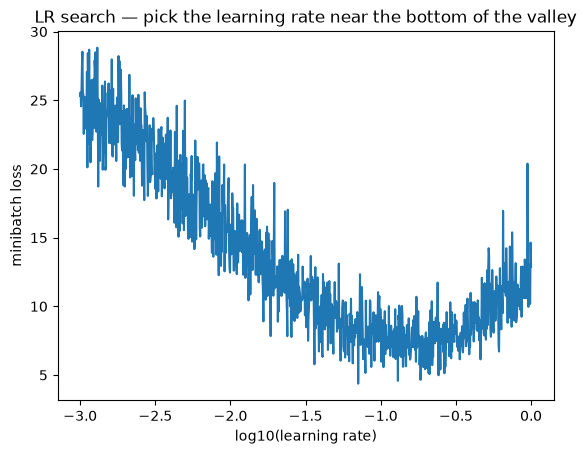

In [9]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre                       # candidate learning rates, 1e-3 .. 1e0

# throwaway copies for the search
gp = torch.Generator().manual_seed(2147483647)
Cs  = torch.randn((vocab_size, emb_dim), generator=gp, requires_grad=True)
W1s = torch.randn((emb_dim*block_size, 200), generator=gp, requires_grad=True)
b1s = torch.randn(200, generator=gp, requires_grad=True)
W2s = torch.randn((200, vocab_size), generator=gp, requires_grad=True)
b2s = torch.randn(vocab_size, generator=gp, requires_grad=True)
ps = [Cs, W1s, b1s, W2s, b2s]

lossi, lrei = [], []
for i in range(1000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = Cs[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1s + b1s)
    loss = F.cross_entropy(h @ W2s + b2s, Ytr[ix])
    for p in ps: p.grad = None
    loss.backward()
    for p in ps: p.data += -lrs[i] * p.grad
    lrei.append(lre[i].item()); lossi.append(loss.item())

plt.plot(lrei, lossi); plt.xlabel("log10(learning rate)"); plt.ylabel("minibatch loss")
plt.title("LR search — pick the learning rate near the bottom of the valley"); plt.show()

## 12. Training — minibatch SGD with a learning-rate decay

Two practical choices make training fast:

- **Minibatches.** Computing the loss/gradient on all ~180k training examples every step is wasteful.
  Instead each step uses a **random batch of 32** (`torch.randint`). The gradient is noisier but ~thousands
  of times cheaper, so we take **far more** steps — a much better use of compute. This is *stochastic*
  gradient descent.
- **Learning-rate decay.** Start at $\eta=0.1$ to move fast, then drop to $0.01$ to settle into the
  minimum without bouncing around it.

The loop is the same three steps as always (forward → backward → update). We plot $\log_{10}$ of the loss
because the noisy minibatch loss is easier to read on a log scale. *(Scaled to 30k steps for runtime; the
lecture runs ~200k for a lower loss.)*

In [10]:
steps = 30000
lossi, stepi = [], []
for i in range(steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))          # minibatch of 32

    # forward
    emb = C[Xtr[ix]]                                    # (32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)          # (32, 200)
    logits = h @ W2 + b2                                # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward
    for p in parameters: p.grad = None
    loss.backward()

    # update with a simple LR decay
    lr = 0.1 if i < 20000 else 0.01
    for p in parameters: p.data += -lr * p.grad

    stepi.append(i); lossi.append(loss.log10().item())
    if i % 5000 == 0:
        print(f"step {i:6d}   minibatch loss {loss.item():.4f}")
print("final minibatch loss:", loss.item())

step      0   minibatch loss 29.7797


step   5000   minibatch loss 2.7295


step  10000   minibatch loss 2.7189


step  15000   minibatch loss 2.3625


step  20000   minibatch loss 2.2538


step  25000   minibatch loss 2.2109


final minibatch loss: 2.496149778366089


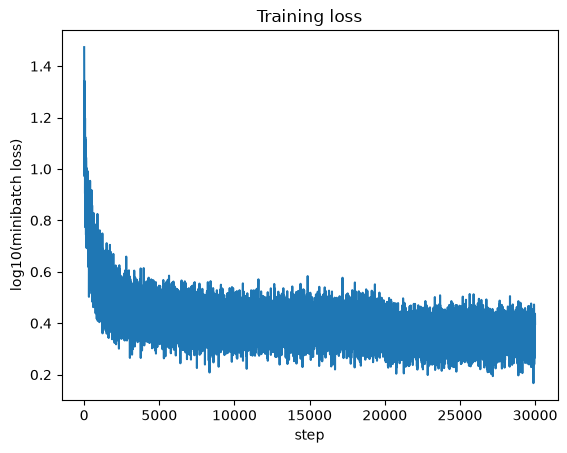

In [11]:
plt.plot(stepi, lossi); plt.xlabel("step"); plt.ylabel("log10(minibatch loss)")
plt.title("Training loss"); plt.show()

## 13. Train vs dev loss — is it learning or memorizing?

Now evaluate on the **full** train split and the **held-out dev** split (no minibatch noise). The two
numbers being **close** means the model is generalizing, not memorizing — and that both are well below the
bigram model's **2.45** means the extra context and the hidden layer genuinely helped. If train were far
below dev we'd be overfitting; if both were high and equal we'd be underfitting and would grow the
network.

In [12]:
@torch.no_grad()
def split_loss(X, Y):
    emb = C[X]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    return F.cross_entropy(h @ W2 + b2, Y).item()

print(f"train loss : {split_loss(Xtr,  Ytr):.4f}")
print(f"dev   loss : {split_loss(Xdev, Ydev):.4f}")
print("(bigram model from Part 1 was ~2.45 — more context + a hidden layer beat it)")

train loss : 2.2566
dev   loss : 2.2671
(bigram model from Part 1 was ~2.45 — more context + a hidden layer beat it)


## 14. Visualizing the embedding space

The embedding table $C$ started as random noise; training shaped it. To *see* the structure, here is a
companion model trained with a **2-dimensional** embedding (so we can plot it directly). Even in 2D, the
network discovers meaningful geometry — notably the **vowels cluster together**, because they're
interchangeable in many contexts, so placing them nearby lets the model reuse what it learns. That
clustering *is* the generalization Bengio's design buys.

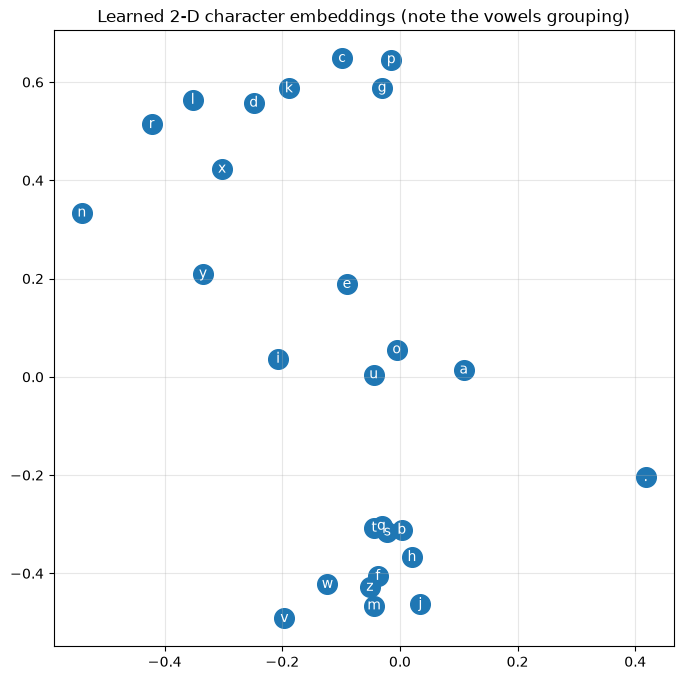

In [13]:
# small 2D-embedding model, trained briefly, purely to visualize the embedding space
g2 = torch.Generator().manual_seed(2147483647)
C2  = torch.randn((vocab_size, 2), generator=g2, requires_grad=True)
W1b = torch.randn((2*block_size, 200), generator=g2, requires_grad=True)
b1b = torch.randn(200, generator=g2, requires_grad=True)
W2b = torch.randn((200, vocab_size), generator=g2, requires_grad=True)
b2b = torch.randn(vocab_size, generator=g2, requires_grad=True)
p2 = [C2, W1b, b1b, W2b, b2b]
for i in range(15000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C2[Xtr[ix]]
    loss = F.cross_entropy(torch.tanh(emb.view(-1, 6) @ W1b + b1b) @ W2b + b2b, Ytr[ix])
    for p in p2: p.grad = None
    loss.backward()
    for p in p2: p.data += -(0.1 if i < 10000 else 0.01) * p.grad

plt.figure(figsize=(8, 8))
plt.scatter(C2[:, 0].data, C2[:, 1].data, s=200)
for i in range(C2.shape[0]):
    plt.text(C2[i, 0].item(), C2[i, 1].item(), itos[i], ha="center", va="center", color='white')
plt.title("Learned 2-D character embeddings (note the vowels grouping)"); plt.grid(True, alpha=.3); plt.show()

## 15. Sampling — generate new names

Generation mirrors Part 1, but the distribution now comes from the full MLP. Start with a context of three
`.`s, run the forward pass to get the next-character probabilities, sample one with `multinomial`, slide it
into the context, and repeat until we sample `.`. Because the model uses three characters of context (and
shares statistical strength through the embeddings), the samples are noticeably **more name-like** than the
bigram model's.

In [14]:
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out, context = [], [0] * block_size
    while True:
        emb = C[torch.tensor([context])]                 # (1, 3, 10)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        out.append(ix)
    print(''.join(itos[i] for i in out))

carmahza
jehlei
kemri
reh
cassanden
jazhuen
deliah
jareei
nerenia
chaiiv
kaleigh
ham
jory
quinn
sroi
marian
quistero
dearyni
jace
pirray


## 16. Summary — what the MLP added over the bigram

| | Bigram (Part 1) | MLP (Part 2, Bengio 2003) |
|---|---|---|
| Context | 1 previous char | `block_size` = 3 previous chars |
| Representation | one-hot (27-dim, sparse) | learned embedding (10-dim, dense) |
| Model | one linear layer + softmax | embed → concat → tanh hidden → linear → softmax |
| How context scales | table size $27^{k}$ — explodes | input grows by `block_size`, params barely change |
| Generalization | none across contexts | similar chars share embeddings |
| Loss (this run) | ~2.45 | ~2.2–2.3 (lower = better) |
| Trained by | counting **or** gradient descent | gradient descent (minibatch SGD) |

**The throughline.** The loss, the softmax, the cross-entropy, and the backprop loop are **unchanged**
from Part 1 — we only enriched the **front of the network**: a learned embedding for each character and a
non-linear hidden layer to mix a window of them. That is the whole recipe for scaling a language model:
keep the training objective fixed, give the network more context and more capacity to represent it. The
next parts of the series push exactly this further (deeper nets, better initialization and normalization,
and eventually attention) — all on top of the foundation you just built.